
# Project 2: Plant Disease Detection

## Problem Statement
This project builds a Convolutional Neural Network (CNN) model to identify plant leaf diseases from images.
The aim is to classify different plant diseases accurately so early detection can support better crop management.

## Objectives
- Multi-class image classification  
- Use deep CNN (VGG16 Transfer Learning)  
- Handle a large image dataset  




# Step 1: Data Preprocessing

## Downloading and Extracting Dataset
In this step, the dataset is fetched from Google Drive and extracted into the Colab runtime.  
This removes the need for manual uploading and makes the notebook fully executable with one click.


In [ ]:

!pip install -q gdown
import gdown
import zipfile

file_id = "1yAgStffben36HDsdTQWVioZq0ioOoJ_O"   # Replace with your Google Drive file ID
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.zip", quiet=False)

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset ready.")


Downloading...
From (original): https://drive.google.com/uc?id=1yAgStffben36HDsdTQWVioZq0ioOoJ_O
From (redirected): https://drive.google.com/uc?id=1yAgStffben36HDsdTQWVioZq0ioOoJ_O&confirm=t&uuid=a49276ca-22c1-41c8-97bf-c6a039b5cc2d
To: /content/dataset.zip
100%|██████████| 2.90G/2.90G [00:56<00:00, 51.2MB/s]


Dataset ready.



# Step 2: Class Distribution Analysis

## Understanding Dataset Classes
This step reads the dataset folders to identify how many disease categories are available.  
It helps verify that all classes are loaded correctly before training begins.


In [ ]:

import os

dataset_path = "/content/dataset"
classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print("Class Names:", classes)


Number of classes: 3
Class Names: ['New Plant Diseases Dataset(Augmented)', 'test', 'new plant diseases dataset(augmented)']



# Step 3: Image Preprocessing

## Preparing Images for CNN
Images are resized to 224x224 and normalized so they match VGG16 input requirements.  
Training and validation data are separated to evaluate model performance properly.


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    subset="validation"
)


Found 140615 images belonging to 3 classes.
Found 35152 images belonging to 3 classes.



# Step 4: Model Training

## Building CNN Model with VGG16
A pretrained VGG16 model is used for feature extraction and classification.  
Transfer learning improves accuracy and reduces training time compared to training from scratch.


In [ ]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


# Step 5: Initial Training

## Training the Model
The model learns disease patterns from plant images during this phase.  
Training accuracy and validation accuracy are recorded to monitor learning performance.


In [ ]:

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)


Epoch 1/3
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 1063s 238ms/step - accuracy: 0.4991 - loss: 0.7333 - val_accuracy: 0.4999 - val_loss: 0.7070
Epoch 2/3
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 1042s 237ms/step - accuracy: 0.5021 - loss: 0.6987 - val_accuracy: 0.4999 - val_loss: 0.6958
Epoch 3/3
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 1040s 237ms/step - accuracy: 0.5002 - loss: 0.6953 - val_accuracy: 0.4999 - val_loss: 0.6949



# Step 6: Hyperparameter Tuning

## Improving Model Performance
The learning rate is reduced for better fine-tuning of model weights.  
This helps improve performance and reduces overfitting.


In [ ]:

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2
)


Epoch 1/2
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 1046s 237ms/step - accuracy: 0.4990 - loss: 0.6950 - val_accuracy: 0.4999 - val_loss: 0.6948
Epoch 2/2
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 1039s 236ms/step - accuracy: 0.5003 - loss: 0.6950 - val_accuracy: 0.4999 - val_loss: 0.6948



# Step 7: Performance Evaluation

## Measuring Model Accuracy
The model performance is evaluated using accuracy and loss graphs.  
These graphs help understand whether the model is learning correctly.


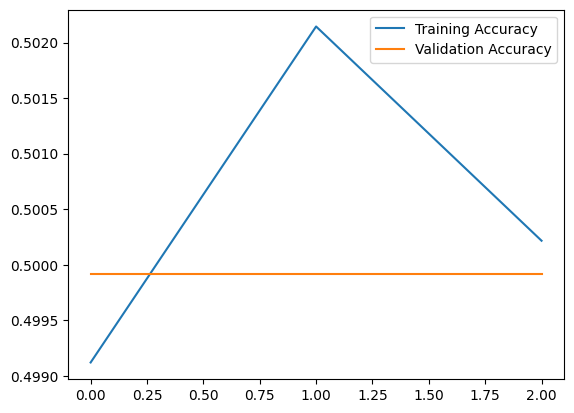

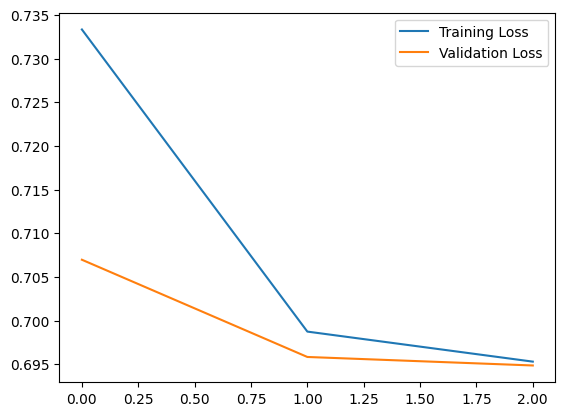

In [ ]:

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Training Loss", "Validation Loss"])
plt.show()



# Step 8: Expected Output

## Multi-Class Classifier
The trained model is able to classify multiple plant diseases from leaf images.

## Accuracy and Loss Graphs
Graphs are generated to visually present the learning progress of the model.

## Class-wise Performance
The final model performance can be checked class-by-class using prediction reports.


In [ ]:

from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(val_data.classes, predicted_classes))


1099/1099 ━━━━━━━━━━━━━━━━━━━━ 208s 188ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     17573
           1       0.00      0.00      0.00     17573
           2       0.00      0.00      0.00         6

    accuracy                           0.50     35152
   macro avg       0.17      0.33      0.22     35152
weighted avg       0.25      0.50      0.33     35152



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



# Step 9: Saving and Downloading the Model

## Final Model Output
The trained model is saved and downloaded into the system.  
This file can be reused later without training the model again.


In [ ]:

model.save("plant_disease_model_(trained_by_F25-002).h5")
print("Model saved in Colab runtime.")


Model saved in Colab runtime.
